# Препроцессинг и извлечение признаков

Ноутбук выполняет финальную обработку очищенного датасета:

1. Создание трёх версий текста: `text_raw`, `text_normalized`, `text_preprocessed`
2. Извлечение 20 числовых признаков через `.apply()`
3. Визуализация препроцессинга (до/после)
4. Удаление строк с пустым `text_preprocessed`
5. Анализ дисбаланса классов
6. Корреляция признаков с целевой переменной
7. Сохранение в `data/processed/preprocessed.csv`

Загружается `data/interim/cleaned.csv`.

In [22]:
import os
import sys
import numpy as np
import pandas as pd

try:
    _project_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    _cwd = os.getcwd()
    _project_root = _cwd
    while _project_root != '/' and not os.path.isdir(os.path.join(_project_root, 'src')):
        _project_root = os.path.dirname(_project_root)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.data.preprocessing import preprocess_text, normalize_unicode, strip_html
from src.features.extractors import (
    count_emojis,
    count_newlines,
    count_whitespaces,
    count_links,
    count_tags,
    capital_ratio,
    count_punctuation,
    count_digits,
    avg_word_length,
    word_count,
    unique_word_ratio,
    repeat_char_ratio,
    count_phone_numbers,
    has_crypto_mention,
    count_exclamation,
    url_ratio,
    count_html_tags,
    has_markdown_formatting,
    emoji_diversity,
)
from src.config import PROCESSED_DIR, INTERIM_DIR

from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_8 = pd.read_csv(INTERIM_DIR / 'cleaned.csv')
print(f'Загружено: {len(df_8)} строк')

Загружено: 77526 строк


## Обработка данных

Текст каждого сообщения проходит предобработку через обновлённый `preprocess_text`:
- Unicode NFKC-нормализация и удаление невидимых/control-символов
- удаление HTML-тегов (`<br>` -> перенос строки, остальные -> удаление)
- замена ссылок и тегов на токены `[LINK]` и `[TAG]`
- приведение к нижнему регистру
- удаление пунктуации (placeholder защищены от удаления)
- удаление эмодзи
- нормализация пробелов

Создаются три версии текста:
- `text_raw` — исходный текст без изменений
- `text_normalized` — NFKC + удаление HTML (для BERT)
- `text_preprocessed` — полная предобработка (для TF-IDF и классических моделей)

Дополнительно извлекаются числовые признаки из исходного текста.

### Создание новых столбцов с числовыми данными

Из исходного текста извлекаются числовые признаки, которые могут
помочь модели классифицировать сообщения.

В спам-сообщениях часто используются эмодзи, ссылки, теги (`@`),
много переносов строк (`\n`) и лишних пробелов.
Количество этих элементов в сообщении может играть большую роль
в классификации.

Извлекаемые признаки:
- `emojis` — количество эмодзи
- `newlines` — количество переносов строк
- `whitespaces` — количество лишних пробелов
- `links` — количество ссылок
- `tags` — количество тегов (`@`)
- `length` — длина текста в символах
- `capital_ratio` — доля заглавных букв (от буквенных символов)
- `punctuation_count` — количество знаков пунктуации
- `digit_count` — количество цифр
- `avg_word_length` — средняя длина слова
- `word_count` — количество слов
- `unique_word_ratio` — доля уникальных слов
- `repeat_char_ratio` — доля повторяющихся символов (3+ подряд)
- `phone_count` — количество телефонных номеров
- `has_crypto` — наличие упоминаний криптовалют
- `exclamation_count` — количество восклицательных знаков
- `url_ratio` — доля текста, занимаемая ссылками
- `html_tag_count` — количество HTML-тегов
- `has_markdown` — наличие markdown-разметки
- `emoji_diversity` — количество уникальных эмодзи

#### Функции для подготовки текста

Функции импортированы из `src.data.preprocessing` и `src.features.extractors`:
- `preprocess_text` — полная нормализация текста (NFKC, HTML, нижний регистр, ссылки, теги, пунктуация, эмодзи)
- `normalize_unicode` — NFKC-нормализация и удаление невидимых символов
- `strip_html` — удаление HTML-тегов
- `count_emojis`, `count_newlines`, `count_whitespaces`, `count_links`, `count_tags`,
  `capital_ratio`, `count_punctuation`, `count_digits`, `avg_word_length`, `word_count`,
  `unique_word_ratio`, `repeat_char_ratio`, `count_phone_numbers`, `has_crypto_mention`,
  `count_exclamation`, `url_ratio` — извлечение числовых признаков
- `count_html_tags`, `has_markdown_formatting`, `emoji_diversity` — новые признаки

#### Подготовка текста и дополнительных числовых данных

Для каждого сообщения:
- сохраняется исходный текст в `text_raw`
- создаётся `text_normalized` (NFKC + удаление HTML, для BERT)
- извлекаются числовые признаки из исходного текста
- выполняется полная предобработка через `preprocess_text` в `text_preprocessed`
- если после предобработки текст пустой, он заменяется на `NaN`

In [3]:
df_preprocessed = deepcopy(df_8)

In [4]:
df_preprocessed['emojis'] = df_8['text'].apply(count_emojis)
df_preprocessed['newlines'] = df_8['text'].apply(count_newlines)
df_preprocessed['whitespaces'] = df_8['text'].apply(count_whitespaces)
df_preprocessed['links'] = df_8['text'].apply(count_links)
df_preprocessed['tags'] = df_8['text'].apply(count_tags)
df_preprocessed['length'] = df_8['text'].str.len()
df_preprocessed['capital_ratio'] = df_8['text'].apply(capital_ratio)
df_preprocessed['punctuation_count'] = df_8['text'].apply(count_punctuation)
df_preprocessed['digit_count'] = df_8['text'].apply(count_digits)
df_preprocessed['avg_word_length'] = df_8['text'].apply(avg_word_length)
df_preprocessed['word_count'] = df_8['text'].apply(word_count)
df_preprocessed['unique_word_ratio'] = df_8['text'].apply(unique_word_ratio)
df_preprocessed['repeat_char_ratio'] = df_8['text'].apply(repeat_char_ratio)
df_preprocessed['phone_count'] = df_8['text'].apply(count_phone_numbers)
df_preprocessed['has_crypto'] = df_8['text'].apply(has_crypto_mention)
df_preprocessed['exclamation_count'] = df_8['text'].apply(count_exclamation)
df_preprocessed['url_ratio'] = df_8['text'].apply(url_ratio)
df_preprocessed['html_tag_count'] = df_8['text'].apply(count_html_tags)
df_preprocessed['has_markdown'] = df_8['text'].apply(has_markdown_formatting)
df_preprocessed['emoji_diversity'] = df_8['text'].apply(emoji_diversity)

In [5]:
print(f'Признаков извлечено: {df_preprocessed.shape[1] - 4} числовых колонок')
print(f'Всего колонок: {df_preprocessed.shape[1]}')

Признаков извлечено: 19 числовых колонок
Всего колонок: 23


In [6]:
df_preprocessed.head()

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,word_count,unique_word_ratio,repeat_char_ratio,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity
0,Добрый день! Отличается ли перечень необходимы...,0,dataset.json,0,0,0,0,0,83,0.027778,...,10,1.000000,0.0,0,0,1,0.0,0,0,0
1,Узбекистан. Рассматриваются обе формы,0,dataset.json,0,0,0,0,0,37,0.060606,...,4,1.000000,0.0,0,0,0,0.0,0,0,0
2,"Здравствуйте, а как проходит поступление после...",0,dataset.json,0,0,0,0,0,147,0.049180,...,22,0.954545,0.0,0,0,0,0.0,0,0,0
3,"Здравствуйте, а когда будет день открытых двер...",0,dataset.json,0,0,0,0,0,62,0.019608,...,10,1.000000,0.0,0,0,0,0.0,0,0,0
4,"Здравствуйте, необходимо для посещения дня отк...",0,dataset.json,0,0,0,0,0,82,0.013889,...,9,1.000000,0.0,0,0,0,0.0,0,0,0


Три версии текста:
- text_raw — исходный текст (без изменений, для reference)
- text_normalized — NFKC + удаление HTML и невидимых символов (для BERT, работает с raw text)
- text_preprocessed — полная предобработка (для классических моделей + TF-IDF)

In [7]:
df_preprocessed['text_raw'] = df_8['text'].values
df_preprocessed['text_normalized'] = df_8['text'].apply(lambda t: normalize_unicode(strip_html(str(t))))
texts = df_8['text'].apply(lambda t: preprocess_text(str(t)))
texts = texts.replace('', np.nan)
df_preprocessed['text_preprocessed'] = texts.values

In [8]:
texts

0        добрый день отличается ли перечень необходимых...
1                     узбекистан рассматриваются обе формы
2        здравствуйте а как проходит поступление после ...
3        здравствуйте а когда будет день открытых двере...
4        здравствуйте необходимо для посещения дня откр...
                               ...                        
77521    очень понравилась книга генри форда время день...
77522    мне кажется что астрология тут может реально п...
77523    недавно дочитал книгу от которой до сих пор вн...
77524    шабашка от 58007000 в день с 16 лет разные про...
77525    прикольно что даже такие важные моменты как пр...
Name: text, Length: 77526, dtype: object

In [9]:
len(texts)

77526

In [10]:
df_preprocessed['text_preprocessed'] = texts

In [11]:
df_preprocessed.head()

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
0,Добрый день! Отличается ли перечень необходимы...,0,dataset.json,0,0,0,0,0,83,0.027778,...,0,0,1,0.0,0,0,0,Добрый день! Отличается ли перечень необходимы...,Добрый день! Отличается ли перечень необходимы...,добрый день отличается ли перечень необходимых...
1,Узбекистан. Рассматриваются обе формы,0,dataset.json,0,0,0,0,0,37,0.060606,...,0,0,0,0.0,0,0,0,Узбекистан. Рассматриваются обе формы,Узбекистан. Рассматриваются обе формы,узбекистан рассматриваются обе формы
2,"Здравствуйте, а как проходит поступление после...",0,dataset.json,0,0,0,0,0,147,0.049180,...,0,0,0,0.0,0,0,0,"Здравствуйте, а как проходит поступление после...","Здравствуйте, а как проходит поступление после...",здравствуйте а как проходит поступление после ...
3,"Здравствуйте, а когда будет день открытых двер...",0,dataset.json,0,0,0,0,0,62,0.019608,...,0,0,0,0.0,0,0,0,"Здравствуйте, а когда будет день открытых двер...","Здравствуйте, а когда будет день открытых двер...",здравствуйте а когда будет день открытых двере...
4,"Здравствуйте, необходимо для посещения дня отк...",0,dataset.json,0,0,0,0,0,82,0.013889,...,0,0,0,0.0,0,0,0,"Здравствуйте, необходимо для посещения дня отк...","Здравствуйте, необходимо для посещения дня отк...",здравствуйте необходимо для посещения дня откр...


#### Визуализация препроцессинга (до/после)

Примеры исходного, нормализованного и полностью предобработанного текста
для каждого класса.

In [13]:
for _label, _label_name in [(0, 'Ham'), (1, 'Spam')]:
    _subset = df_preprocessed[df_preprocessed['label'] == _label].head(5)
    print(f'\n--- {_label_name} (label={_label}) ---')
    for _idx, _row in _subset.iterrows():
        _raw = str(_row['text_raw'])[:100]
        _norm = str(_row['text_normalized'])[:100]
        _prep = str(_row['text_preprocessed'])[:100]
        print(f'\n  text_raw:        {_raw}')
        print(f'  text_normalized: {_norm}')
        print(f'  text_preprocessed: {_prep}')


--- Ham (label=0) ---

  text_raw:        Добрый день! Отличается ли перечень необходимых документов для иностранных граждан?
  text_normalized: Добрый день! Отличается ли перечень необходимых документов для иностранных граждан?
  text_preprocessed: добрый день отличается ли перечень необходимых документов для иностранных граждан

  text_raw:        Узбекистан. Рассматриваются обе формы
  text_normalized: Узбекистан. Рассматриваются обе формы
  text_preprocessed: узбекистан рассматриваются обе формы

  text_raw:        Здравствуйте, а как проходит поступление после колледжа? Внутренний экзамен или только ЕГЭ? И возмож
  text_normalized: Здравствуйте, а как проходит поступление после колледжа? Внутренний экзамен или только ЕГЭ? И возмож
  text_preprocessed: здравствуйте а как проходит поступление после колледжа внутренний экзамен или только егэ и возможно 

  text_raw:        Здравствуйте, а когда будет день открытых дверей и во сколько?
  text_normalized: Здравствуйте, а когда будет д

In [14]:
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77526 entries, 0 to 77525
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   text               77526 non-null  object 
 1   label              77526 non-null  int64  
 2   _source            77526 non-null  object 
 3   emojis             77526 non-null  int64  
 4   newlines           77526 non-null  int64  
 5   whitespaces        77526 non-null  int64  
 6   links              77526 non-null  int64  
 7   tags               77526 non-null  int64  
 8   length             77526 non-null  int64  
 9   capital_ratio      77526 non-null  float64
 10  punctuation_count  77526 non-null  int64  
 11  digit_count        77526 non-null  int64  
 12  avg_word_length    77526 non-null  float64
 13  word_count         77526 non-null  int64  
 14  unique_word_ratio  77526 non-null  float64
 15  repeat_char_ratio  77526 non-null  float64
 16  phone_count        775

### Удаление лишних строк

Удаляются строки, где `text_preprocessed` оказался пустым после предобработки.
Выводится итоговое количество строк и распределение по классам.

In [15]:
sum(df_preprocessed.isnull().sum(axis = 1))

3

In [16]:
df_preprocessed.dropna(subset=['text_preprocessed'], inplace=True)

In [17]:
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77523 entries, 0 to 77525
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   text               77523 non-null  object 
 1   label              77523 non-null  int64  
 2   _source            77523 non-null  object 
 3   emojis             77523 non-null  int64  
 4   newlines           77523 non-null  int64  
 5   whitespaces        77523 non-null  int64  
 6   links              77523 non-null  int64  
 7   tags               77523 non-null  int64  
 8   length             77523 non-null  int64  
 9   capital_ratio      77523 non-null  float64
 10  punctuation_count  77523 non-null  int64  
 11  digit_count        77523 non-null  int64  
 12  avg_word_length    77523 non-null  float64
 13  word_count         77523 non-null  int64  
 14  unique_word_ratio  77523 non-null  float64
 15  repeat_char_ratio  77523 non-null  float64
 16  phone_count        77523 no

In [18]:
count_zero = df_preprocessed[df_preprocessed['label'] == 0].shape[0]

In [19]:
count_zero

59086

In [20]:
count_one = df_preprocessed[df_preprocessed['label'] == 1].shape[0]

In [21]:
count_one

18437

### Анализ дисбаланса классов

Визуализация распределения классов и источников в итоговом датасете.
Дисбаланс не исправляется здесь — балансировка применяется на этапе обучения.

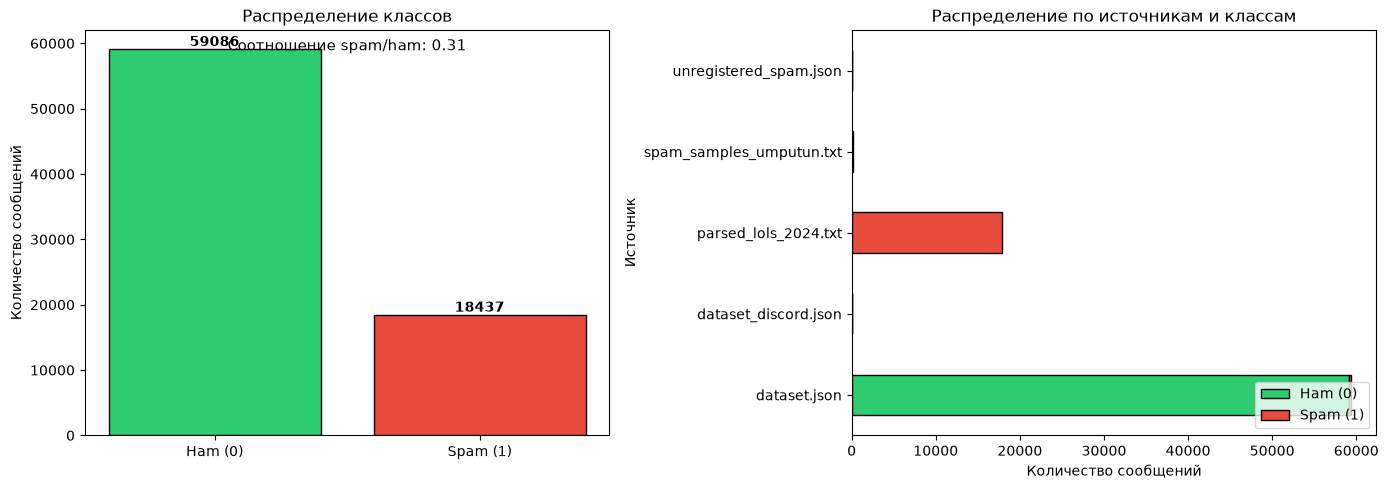


Итого: 77523 строк
  Ham (0): 59086
  Spam (1): 18437
  Соотношение: 0.31


In [23]:
_fig, _axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение классов
_class_counts = df_preprocessed['label'].value_counts().sort_index()
_axes[0].bar(['Ham (0)', 'Spam (1)'], _class_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
for _i, _v in enumerate(_class_counts.values):
    _axes[0].text(_i, _v + 500, str(_v), ha='center', fontweight='bold')
_axes[0].set_title('Распределение классов')
_axes[0].set_ylabel('Количество сообщений')
_ratio = _class_counts.get(1, 0) / max(_class_counts.get(0, 1), 1)
_axes[0].text(0.5, 0.95, f'Соотношение spam/ham: {_ratio:.2f}', transform=_axes[0].transAxes, ha='center', fontsize=11)

# Распределение по источникам и классам
_source_class = df_preprocessed.groupby(['_source', 'label']).size().unstack(fill_value=0)
_source_class.plot(kind='barh', stacked=True, ax=_axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
_axes[1].set_title('Распределение по источникам и классам')
_axes[1].set_xlabel('Количество сообщений')
_axes[1].set_ylabel('Источник')
_axes[1].legend(['Ham (0)', 'Spam (1)'], loc='lower right')

plt.tight_layout()
plt.show()

print(f'\nИтого: {len(df_preprocessed)} строк')
print(f"  Ham (0): {len(df_preprocessed[df_preprocessed['label'] == 0])}")
print(f"  Spam (1): {len(df_preprocessed[df_preprocessed['label'] == 1])}")
print(f"  Соотношение: {_ratio:.2f}")

### Выявление корреляции между новыми параметрами и целевой переменной

Для каждого числового признака выполняется сортировка датафрейма
по убыванию и визуальный анализ распределения классов.
Затем вычисляется полная корреляционная матрица.

Количество эмодзи действительно может влиять на результативность модели.
Спам-сообщения часто содержат больше эмодзи, чем обычные.

In [24]:
df_preprocessed.sort_values('emojis', ascending=False)

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
62089,🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸<br>🌸🌸🌸🌸🌸🍋🍋🌸🌸🌸🍋🍋🌸🌸🌸🌸🌸\n🌸🌸🌸🌸🍋🍋...,1,parsed_lols_2024.txt,466,38,19,1,0,1082,0.209677,...,0,0,0,0.024954,1,0,3,🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸<br>🌸🌸🌸🌸🌸🍋🍋🌸🌸🌸🍋🍋🌸🌸🌸🌸🌸\n🌸🌸🌸🌸🍋🍋...,🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸\n🌸🌸🌸🌸🌸🍋🍋🌸🌸🌸🍋🍋🌸🌸🌸🌸🌸\n🌸🌸🌸🌸🍋🍋🍋🍋...,retention manager горячий трафик ру много слад...
70487,СБЕРБАНК КАРТА 💳💳 АЛАМ<br>\n💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵...,1,parsed_lols_2024.txt,424,203,107,0,0,3232,0.969123,...,14,0,0,0.000000,1,0,14,СБЕРБАНК КАРТА 💳💳 АЛАМ<br>\n💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵...,СБЕРБАНК КАРТА 💳💳 АЛАМ\n\n💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵💵...,сбербанк карта алам сбербанк карта алам сбер 2...
62911,🔥ЖИДКОСТИ🔥<br>😎БОЛЕЕ 5000 ДОВОЛЬНЫХ КЛИЕНТОВ😎\...,1,parsed_lols_2024.txt,356,169,16,0,0,3039,0.456963,...,0,0,0,0.000000,1,0,40,🔥ЖИДКОСТИ🔥<br>😎БОЛЕЕ 5000 ДОВОЛЬНЫХ КЛИЕНТОВ😎\...,🔥ЖИДКОСТИ🔥\n😎БОЛЕЕ 5000 ДОВОЛЬНЫХ КЛИЕНТОВ😎\n🥰...,жидкости более 5000 довольных клиентов blood h...
60575,🔺SALES MANAGER🔺<br>♦️МЕНЕДЖЕР ПО ПРОДАЖАМ♦️\n\...,1,parsed_lols_2024.txt,319,82,30,0,0,2468,0.797994,...,0,0,10,0.000000,1,0,10,🔺SALES MANAGER🔺<br>♦️МЕНЕДЖЕР ПО ПРОДАЖАМ♦️\n\...,🔺SALES MANAGER🔺\n♦️МЕНЕДЖЕР ПО ПРОДАЖАМ♦️\n\n\...,sales manager менеджер по продажам киев оболон...
75764,😤😤😤😤 <br>\n😤😤😤😤😤\n\n🟣БЕРЕМ РЕБЯТ С ОПЫТОМ И...,1,parsed_lols_2024.txt,267,129,47,0,0,2450,0.671482,...,0,0,2,0.000000,1,0,35,😤😤😤😤 <br>\n😤😤😤😤😤\n\n🟣БЕРЕМ РЕБЯТ С ОПЫТОМ И...,😤😤😤😤 \n\n😤😤😤😤😤\n\n🟣БЕРЕМ РЕБЯТ С ОПЫТОМ И Б...,берем ребят с опытом и без не ставим дедлайн в...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77513,Классная идея! Знаки действительно могут подск...,1,unregistered_spam.json,0,0,0,0,1,294,0.020000,...,0,0,1,0.000000,0,0,0,Классная идея! Знаки действительно могут подск...,Классная идея! Знаки действительно могут подск...,классная идея знаки действительно могут подска...
77515,горит контролер который будет смотреть за тер...,1,unregistered_spam.json,0,0,1,0,0,108,0.000000,...,0,0,0,0.000000,0,0,0,горит контролер который будет смотреть за тер...,горит контролер который будет смотреть за тер...,горит контролер который будет смотреть за терр...
77517,"Ой да точно, смех — это такая классная штука, ...",1,unregistered_spam.json,0,0,0,0,1,310,0.019763,...,0,0,1,0.000000,0,0,0,"Ой да точно, смех — это такая классная штука, ...","Ой да точно, смех — это такая классная штука, ...",ой да точно смех это такая классная штука помо...
77518,"привет всем, кто-нибудь пробовал оплатить зару...",1,unregistered_spam.json,0,0,0,0,0,114,0.000000,...,0,0,0,0.000000,0,0,0,"привет всем, кто-нибудь пробовал оплатить зару...","привет всем, кто-нибудь пробовал оплатить зару...",привет всем ктонибудь пробовал оплатить зарубе...


Количество символов новой строки не показывает явной закономерности
с целевой переменной.

In [25]:
df_preprocessed.sort_values('newlines', ascending=False)

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
59669,"ʙᥴᥱⲙ ᤋдρᥲʙᥴᴛʙуᥔᴛᥱ ,<br>ᥙ ϶ᴛ᧐ нᥲδ᧐ρ ʙ᧐ ɸ᧘уд\n""н...",1,parsed_lols_2024.txt,81,236,82,0,0,2042,0.115811,...,0,0,2,0.000000,1,0,3,"ʙᥴᥱⲙ ᤋдρᥲʙᥴᴛʙуᥔᴛᥱ ,<br>ᥙ ϶ᴛ᧐ нᥲδ᧐ρ ʙ᧐ ɸ᧘уд\n""н...","ʙᥴᥱⲙ ᤋдρᥲʙᥴᴛʙуᥔᴛᥱ ,\nᥙ ϶ᴛ᧐ нᥲδ᧐ρ ʙ᧐ ɸ᧘уд\n""нᥱɸ...",ʙᥴᥱⲙ ᤋдρᥲʙᥴᴛʙуᥔᴛᥱ ᥙ ᴛ᧐ нᥲδ᧐ρ ʙ᧐ ɸ᧘уд нᥱɸᥙκ᧐ρ᧐ʙ...
71757,🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠<br>\n\n🥶🥶🥶 \n\n\n⭐𝗡𝗘𝗧𝗙𝗟𝗜𝗫 𝗣...,1,parsed_lols_2024.txt,84,228,125,0,3,2829,0.615570,...,0,1,0,0.000000,1,0,17,🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠<br>\n\n🥶🥶🥶 \n\n\n⭐𝗡𝗘𝗧𝗙𝗟𝗜𝗫 𝗣...,🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠\n\n\n🥶🥶🥶 \n\n\n⭐NETFLIX PRI...,netflix priv screen 1 month 99ɪɴʀ2ᴜsᴅ 3 month ...
63279,꧁𓊈𒆜 𝔹𝔼𝕊𝕋 𝕊𝔼ℝ𝕍𝕀ℂ𝔼 𒆜𓊉꧂<br>••••••••••••••••••••••...,1,parsed_lols_2024.txt,140,226,109,8,16,3374,0.481178,...,0,0,0,0.080616,1,0,13,꧁𓊈𒆜 𝔹𝔼𝕊𝕋 𝕊𝔼ℝ𝕍𝕀ℂ𝔼 𒆜𓊉꧂<br>••••••••••••••••••••••...,꧁𓊈𒆜 BEST SERVICE 𒆜𓊉꧂\n••••••••••••••••••••••••...,𓊈𒆜 best service 𒆜𓊉 lifetime blue tick rs999 36...
66838,🔫🔫🔫 🔫🔫🔫🔫🔫<br>\n\n🥶🥶🥶 \n\n\n⭐𝗡𝗘𝗧𝗙𝗟𝗜𝗫 𝗣𝗥𝗜𝗩 𝗦𝗖...,1,parsed_lols_2024.txt,82,223,122,0,3,2372,0.725550,...,0,0,0,0.000000,1,0,17,🔫🔫🔫 🔫🔫🔫🔫🔫<br>\n\n🥶🥶🥶 \n\n\n⭐𝗡𝗘𝗧𝗙𝗟𝗜𝗫 𝗣𝗥𝗜𝗩 𝗦𝗖...,🔫🔫🔫 🔫🔫🔫🔫🔫\n\n\n🥶🥶🥶 \n\n\n⭐NETFLIX PRIV SCRE...,netflix priv screen 1 month 99ɪɴʀ2ᴜsᴅ 3 month ...
62891,🔤🔤🔤🔤🔤🔤<br><br><br>🔠🔠🔠🔠🔠🔠🔠🔠 🔠🔠🔠🔠\n\n\n\nБЕСПЛА...,1,parsed_lols_2024.txt,76,222,112,0,2,3132,0.651022,...,0,0,0,0.000000,3,1,8,🔤🔤🔤🔤🔤🔤<br><br><br>🔠🔠🔠🔠🔠🔠🔠🔠 🔠🔠🔠🔠\n\n\n\nБЕСПЛА...,🔤🔤🔤🔤🔤🔤\n\n\n🔠🔠🔠🔠🔠🔠🔠🔠 🔠🔠🔠🔠\n\n\n\nБЕСПЛАТНАЯ Д...,бесплатная доставка по метро почтой по рб дост...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43105,Можете написать ФИО — посмотрим,0,dataset.json,0,0,0,0,0,31,0.153846,...,0,0,0,0.000000,0,0,0,Можете написать ФИО — посмотрим,Можете написать ФИО — посмотрим,можете написать фио посмотрим
43102,На данный момент — нет. Это суммарный проходно...,0,dataset.json,0,0,0,0,0,159,0.023077,...,0,0,0,0.000000,0,0,0,На данный момент — нет. Это суммарный проходно...,На данный момент — нет. Это суммарный проходно...,на данный момент нет это суммарный проходной б...
43101,Вам нужно в личном кабинете ab.rudn.ru добавит...,0,dataset.json,0,0,0,1,0,77,0.015385,...,0,0,0,0.129870,0,0,0,Вам нужно в личном кабинете ab.rudn.ru добавит...,Вам нужно в личном кабинете ab.rudn.ru добавит...,вам нужно в личном кабинете [LINK] добавить но...
43093,В течение 5 рабочих дней на почту придёт уведо...,0,dataset.json,0,0,0,0,0,62,0.019608,...,0,0,0,0.000000,0,0,0,В течение 5 рабочих дней на почту придёт уведо...,В течение 5 рабочих дней на почту придёт уведо...,в течение 5 рабочих дней на почту придёт уведо...


Количество лишних пробелов может влиять на результативность модели.

In [26]:
df_preprocessed.sort_values('whitespaces', ascending=False)

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
71658,Занимаемcя поставкой теxники Sаmsung из ОАЭ🇦🇪 ...,1,parsed_lols_2024.txt,93,182,172,5,0,2464,0.249237,...,0,0,0,0.046672,1,0,18,Занимаемcя поставкой теxники Sаmsung из ОАЭ🇦🇪 ...,Занимаемcя поставкой теxники Sаmsung из ОАЭ🇦🇪 ...,занимаемcя поставкой теxники sаmsung из оаэ да...
69059,🤖 П р о в е р ь д е в у ш е к ...,1,parsed_lols_2024.txt,12,21,166,0,4,637,0.140000,...,0,0,0,0.000000,2,0,3,🤖 П р о в е р ь д е в у ш е к ...,🤖 П р о в е р ь д е в у ш е к ...,п р о в е р ь д е в у ш е к н а и н т и м н ы ...
68993,И н т и м к и с п о м о щ ь...,1,parsed_lols_2024.txt,12,15,162,0,4,635,0.134831,...,0,0,0,0.000000,1,0,3,И н т и м к и с п о м о щ ь...,И н т и м к и с п о м о щ ь...,и н т и м к и с п о м о щ ь ю и и н о в ы е т ...
70229,💔🔠🔠🔠 🔠🔠🔠🔠🔠🔠🔠🔠 💔<br>\n⚡ NETFLIX CRACK \n⚡ NETF...,1,parsed_lols_2024.txt,165,182,136,0,0,2823,0.864266,...,0,1,0,0.000000,1,0,9,💔🔠🔠🔠 🔠🔠🔠🔠🔠🔠🔠🔠 💔<br>\n⚡ NETFLIX CRACK \n⚡ NETF...,💔🔠🔠🔠 🔠🔠🔠🔠🔠🔠🔠🔠 💔\n\n⚡ NETFLIX CRACK \n⚡ NETFLI...,netflix crack netflix 3 rd party netflix priva...
71757,🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠<br>\n\n🥶🥶🥶 \n\n\n⭐𝗡𝗘𝗧𝗙𝗟𝗜𝗫 𝗣...,1,parsed_lols_2024.txt,84,228,125,0,3,2829,0.615570,...,0,1,0,0.000000,1,0,17,🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠<br>\n\n🥶🥶🥶 \n\n\n⭐𝗡𝗘𝗧𝗙𝗟𝗜𝗫 𝗣...,🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠\n\n\n🥶🥶🥶 \n\n\n⭐NETFLIX PRI...,netflix priv screen 1 month 99ɪɴʀ2ᴜsᴅ 3 month ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24242,я перепутал,0,dataset.json,0,0,0,0,0,11,0.000000,...,0,0,0,0.000000,0,0,0,я перепутал,я перепутал,я перепутал
24241,я 30 из 46,0,dataset.json,0,0,0,0,0,10,0.000000,...,0,0,0,0.000000,0,0,0,я 30 из 46,я 30 из 46,я 30 из 46
24240,кого больше тот и прав,0,dataset.json,0,0,0,0,0,22,0.000000,...,0,0,0,0.000000,0,0,0,кого больше тот и прав,кого больше тот и прав,кого больше тот и прав
24239,"выгоняйте всех людей и обновляйте списки, нас ...",0,dataset.json,0,0,0,0,0,52,0.000000,...,0,0,0,0.000000,0,0,0,"выгоняйте всех людей и обновляйте списки, нас ...","выгоняйте всех людей и обновляйте списки, нас ...",выгоняйте всех людей и обновляйте списки нас б...


Количество ссылок может влиять на результативность модели.

In [27]:
df_preprocessed.sort_values('links', ascending=False)

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
67420,"Completely FREE,crypto earning,NO deposit,NO i...",1,parsed_lols_2024.txt,0,101,0,101,0,3864,0.038699,...,17,1,1,0.955487,1,0,0,"Completely FREE,crypto earning,NO deposit,NO i...","Completely FREE,crypto earning,NO deposit,NO i...",completely freecrypto earningno depositno inve...
70936,"Completely FREE,crypto earning,NO deposit,NO i...",1,parsed_lols_2024.txt,0,85,0,85,0,3412,0.058450,...,4,1,1,0.954279,1,1,0,"Completely FREE,crypto earning,NO deposit,NO i...","Completely FREE,crypto earning,NO deposit,NO i...",completely freecrypto earningno depositno inve...
67680,https://bnbhs.com/ref/193822319366<br>https://...,1,parsed_lols_2024.txt,0,83,0,83,0,3770,0.141146,...,5,0,0,0.976658,1,0,0,https://bnbhs.com/ref/193822319366<br>https://...,https://bnbhs.com/ref/193822319366\nhttps://mi...,[LINK] [LINK] [LINK] [LINK] [LINK] [LINK] [LIN...
72537,"🐍KOBRA🐍1010🐍, [30.09.2023 13:12]<br>🐍KOBRA🐍101...",1,parsed_lols_2024.txt,16,105,19,69,0,3138,0.247348,...,0,0,0,0.813576,1,0,4,"🐍KOBRA🐍1010🐍, [30.09.2023 13:12]<br>🐍KOBRA🐍101...","🐍KOBRA🐍1010🐍, [30.09.2023 13:12]\n🐍KOBRA🐍1010🐍...",kobra1010 30092023 1312 kobra1010 28072023 171...
75943,Hello 👋 are you ready to receive instant funds...,1,parsed_lols_2024.txt,9,170,84,57,0,2859,0.276174,...,0,0,4,0.586219,1,0,6,Hello 👋 are you ready to receive instant funds...,Hello 👋 are you ready to receive instant funds...,hello are you ready to receive instant funds j...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77515,горит контролер который будет смотреть за тер...,1,unregistered_spam.json,0,0,1,0,0,108,0.000000,...,0,0,0,0.000000,0,0,0,горит контролер который будет смотреть за тер...,горит контролер который будет смотреть за тер...,горит контролер который будет смотреть за терр...
77514,"Интересная штука, связать цветы с астрологией!...",1,unregistered_spam.json,1,0,0,0,1,278,0.013043,...,0,0,1,0.000000,0,0,1,"Интересная штука, связать цветы с астрологией!...","Интересная штука, связать цветы с астрологией!...",интересная штука связать цветы с астрологией п...
77513,Классная идея! Знаки действительно могут подск...,1,unregistered_spam.json,0,0,0,0,1,294,0.020000,...,0,0,1,0.000000,0,0,0,Классная идея! Знаки действительно могут подск...,Классная идея! Знаки действительно могут подск...,классная идея знаки действительно могут подска...
77512,"Прикольно, как астрология проникает в повседне...",1,unregistered_spam.json,0,0,0,0,1,375,0.025641,...,0,0,1,0.000000,0,0,0,"Прикольно, как астрология проникает в повседне...","Прикольно, как астрология проникает в повседне...",прикольно как астрология проникает в повседнев...


Количество тегов может влиять на результативность модели.

In [28]:
df_preprocessed.sort_values('tags', ascending=False)

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
66833,✔️ SORGU PANELİ SATIN ALMAK İÇİN ✔️<br>\n\n\n@...,1,parsed_lols_2024.txt,13,97,36,0,91,1340,0.207057,...,0,0,0,0.000000,1,0,3,✔️ SORGU PANELİ SATIN ALMAK İÇİN ✔️<br>\n\n\n@...,✔️ SORGU PANELİ SATIN ALMAK İÇİN ✔️\n\n\n\n@Jo...,sorgu paneli satin almak için [TAG] [TAG] [TAG...
68063,💠SHARE YOUR LINK💠<br>\n𝟖𝟎 𝐠𝐫𝐨𝐮𝐩𝐬 𝐟𝐨𝐫 𝐥𝐢𝐧𝐤 𝐬𝐡𝐚𝐫...,1,parsed_lols_2024.txt,2,91,93,2,81,1994,0.209976,...,0,0,0,0.036108,1,1,1,💠SHARE YOUR LINK💠<br>\n𝟖𝟎 𝐠𝐫𝐨𝐮𝐩𝐬 𝐟𝐨𝐫 𝐥𝐢𝐧𝐤 𝐬𝐡𝐚𝐫...,💠SHARE YOUR LINK💠\n\n80 groups for link share....,share your link 80 groups for link share [LINK...
69717,👑👑SHARE LINK👑👑<br>\n𝟖𝟎 𝐠𝐫𝐨𝐮𝐩𝐬 𝐟𝐨𝐫 𝐥𝐢𝐧𝐤 𝐬𝐡𝐚𝐫𝐞.-...,1,parsed_lols_2024.txt,4,88,92,2,80,1924,0.168224,...,0,0,0,0.033264,1,1,1,👑👑SHARE LINK👑👑<br>\n𝟖𝟎 𝐠𝐫𝐨𝐮𝐩𝐬 𝐟𝐨𝐫 𝐥𝐢𝐧𝐤 𝐬𝐡𝐚𝐫𝐞.-...,👑👑SHARE LINK👑👑\n\n80 groups for link share.- \...,share link 80 groups for link share [LINK] 1 [...
68269,🔠🔠🔠🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠 <br>UCRETSİZ PLAKA SORGU AKT...,1,parsed_lols_2024.txt,99,43,38,0,72,1584,0.222820,...,0,0,0,0.000000,1,0,2,🔠🔠🔠🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠 <br>UCRETSİZ PLAKA SORGU AKT...,🔠🔠🔠🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠 \nUCRETSİZ PLAKA SORGU AKTİF...,ucretsiz plaka sorgu aktif [TAG] [TAG] [TAG] [...
63607,🔠🔠🔠🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠 <br>\n@xmlcity_bot @xmlcity_...,1,parsed_lols_2024.txt,99,43,41,0,72,1350,0.000000,...,0,0,0,0.000000,1,0,2,🔠🔠🔠🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠 <br>\n@xmlcity_bot @xmlcity_...,🔠🔠🔠🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠 \n\n@xmlcity_bot @xmlcity_bo...,[TAG] [TAG] [TAG] [TAG] [TAG] [TAG] [TAG] [TAG...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25632,я в прошлых семестрах узнал о том на какие пар...,0,dataset.json,0,0,0,0,0,159,0.000000,...,0,0,0,0.000000,0,0,0,я в прошлых семестрах узнал о том на какие пар...,я в прошлых семестрах узнал о том на какие пар...,я в прошлых семестрах узнал о том на какие пар...
25631,а если еще будут пересекатся.......,0,dataset.json,0,0,0,0,0,35,0.000000,...,0,0,0,0.000000,0,0,0,а если еще будут пересекатся.......,а если еще будут пересекатся.......,а если еще будут пересекатся
25630,а то еще поставят пары на утро,0,dataset.json,0,0,0,0,0,30,0.000000,...,0,0,0,0.000000,0,0,0,а то еще поставят пары на утро,а то еще поставят пары на утро,а то еще поставят пары на утро
25629,"Не могу ответить на Ваши вопросы, так как пра...",0,dataset.json,3,0,1,0,0,127,0.030612,...,0,0,0,0.000000,0,0,3,"Не могу ответить на Ваши вопросы, так как пра...","Не могу ответить на Ваши вопросы, так как пра...",не могу ответить на ваши вопросы так как практ...


Для проверки корреляции из датафрейма удаляются текстовые колонки,
остаются только числовые признаки и метка класса.

In [29]:
df_corr = deepcopy(df_preprocessed)
df_corr = df_corr.drop(columns=['text', 'text_raw', 'text_normalized', 'text_preprocessed'], errors='ignore')
df_corr.drop(columns=['_source'], errors='ignore', inplace=True)

In [30]:
df_corr.corr()

,label,emojis,newlines,whitespaces,links,tags,length,capital_ratio,punctuation_count,digit_count,...,word_count,unique_word_ratio,repeat_char_ratio,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity
label,1.000000,0.402096,0.381392,0.362236,0.190376,0.207089,0.223563,0.344297,0.381551,0.303715,...,0.235943,-0.316364,0.202799,0.034134,0.336397,0.142615,0.130451,0.695371,0.155780,0.432377
emojis,0.402096,1.000000,0.763673,0.697342,0.407166,0.248532,0.493320,0.310734,0.776914,0.570072,...,0.477315,-0.488670,0.218827,0.094064,0.334359,0.116868,0.216459,0.404622,0.062998,0.818922
newlines,0.381392,0.763673,1.000000,0.897338,0.512549,0.323959,0.773193,0.285402,0.822803,0.751385,...,0.767714,-0.663373,0.129771,0.204145,0.359991,0.220369,0.231776,0.396526,0.180473,0.760411
whitespaces,0.362236,0.697342,0.897338,1.000000,0.433211,0.307207,0.697295,0.262992,0.736262,0.651802,...,0.695009,-0.624284,0.182167,0.158597,0.326920,0.194695,0.206619,0.373412,0.164587,0.698778
links,0.190376,0.407166,0.512549,0.433211,1.000000,0.109243,0.368695,0.105082,0.554822,0.652846,...,0.269027,-0.326956,0.062576,0.373566,0.270839,0.024173,0.515185,0.178365,0.027520,0.372348
tags,0.207089,0.248532,0.323959,0.307207,0.109243,1.000000,0.235474,0.138122,0.289584,0.236478,...,0.227530,-0.251118,0.058285,0.107343,0.114892,0.086150,0.033223,0.196525,0.076160,0.246589
length,0.223563,0.493320,0.773193,0.697295,0.368695,0.235474,1.000000,0.122872,0.685235,0.582475,...,0.974590,-0.682505,0.040007,0.193244,0.244163,0.283072,0.138872,0.257090,0.201726,0.567525
capital_ratio,0.344297,0.310734,0.285402,0.262992,0.105082,0.138122,0.122872,1.000000,0.253270,0.192363,...,0.123902,-0.213116,0.159516,0.015990,0.139282,0.085913,0.085511,0.301636,0.035063,0.299632
punctuation_count,0.381551,0.776914,0.822803,0.736262,0.554822,0.289584,0.685235,0.253270,1.000000,0.720617,...,0.642323,-0.578182,0.165736,0.186232,0.356873,0.193858,0.278504,0.390928,0.141804,0.714588
digit_count,0.303715,0.570072,0.751385,0.651802,0.652846,0.236478,0.582475,0.192363,0.720617,1.000000,...,0.554138,-0.524251,0.113506,0.394007,0.329630,0.106705,0.306775,0.298317,0.111799,0.533573


Итоги корреляции:
- **Эмодзи**, **лишние пробелы**, **переносы строк** оказывают **умеренное влияние** на предсказание класса (`label`).
- **Ссылки** и **тэги** имеют **слабую корреляцию с целевой переменной**, но их использование может быть полезно в сочетании с другими признаками.
- Новые признаки (`html_tag_count`, `has_markdown`, `emoji_diversity`) могут дополнительно улучшить классификацию.

## Сохранение данных

Итоговый датасет сохраняется в `data/processed/preprocessed.csv`.
Колонка `_source` сохраняется для per-source анализа в последующих ноутбуках.
Этот файл используется во всех последующих ноутбуках для обучения моделей.

In [31]:
df_preprocessed.to_csv(PROCESSED_DIR / 'preprocessed.csv', index=False)
print(f'Сохранено: {len(df_preprocessed)} строк, {df_preprocessed.shape[1]} колонок')
print(f'Колонки: {list(df_preprocessed.columns)}')

Сохранено: 77523 строк, 26 колонок
Колонки: ['text', 'label', '_source', 'emojis', 'newlines', 'whitespaces', 'links', 'tags', 'length', 'capital_ratio', 'punctuation_count', 'digit_count', 'avg_word_length', 'word_count', 'unique_word_ratio', 'repeat_char_ratio', 'phone_count', 'has_crypto', 'exclamation_count', 'url_ratio', 'html_tag_count', 'has_markdown', 'emoji_diversity', 'text_raw', 'text_normalized', 'text_preprocessed']
